In [11]:
import re
import matplotlib.pyplot as plt
import numpy as np          
f=open('WhatsApp Chat with Asmit.txt','r',encoding='utf-8')
data=f.read()
print(data)
pattern='\d{2}/\d{2}/\d{2}, \d{1,2}:\d{2}\u202f(?:am|pm) -\s'



<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\debaditya\AppData\Local\Temp\ipykernel_7008\3999270315.py:7: SyntaxWarning: invalid escape sequence '\d'
  pattern='\d{2}/\d{2}/\d{2}, \d{1,2}:\d{2}\u202f(?:am|pm) -\s'


03/10/24, 9:05 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
03/10/24, 9:06 pm - Asmit: Grp e vai dumdum bol
04/10/24, 6:58 pm - Asmit: Berobi
04/10/24, 6:58 pm - Debaditya Mukherjee: Na
04/10/24, 6:58 pm - Asmit: Acha
04/10/24, 10:30 pm - Asmit: Oye
04/10/24, 10:46 pm - Debaditya Mukherjee: Bol
04/10/24, 10:47 pm - Asmit: Kalke bari thkbi 6 ty
04/10/24, 10:47 pm - Debaditya Mukherjee: Ha
04/10/24, 10:48 pm - Asmit: Gublu amke phn korechilo or ki ekta bag ache rakhte bollo khela dekhte jawar ache kalke sondhete pora thakbe mone hoy amar to Ami jodi nite na pari bag ta tui ki or bag ta rakhte parbi tor barite?
04/10/24, 10:50 pm - Debaditya Mukherjee: Bag?
04/10/24, 10:51 pm - Debaditya Mukherjee: O ki edike ashe naki porte
04/10/24, 10:54 pm - Asmit: Se jni kthy jay tor bridge er samne asbe
04/10/24, 10:54 pm - Asmit: Haaa
04/10/24, 10:54 pm - Asmit: Tui ki rakhte parbi?
04/10/24, 10:54 pm - Asmit: Ar phone ko

In [12]:
messeges=re.split(pattern,data)
messeges=messeges[2:]
fixed1=[]
for text in messeges:
    fixed1.append(text.replace("\n", " "))
print(len(fixed1))

7384


In [13]:
dates=re.findall(pattern,data)
dates=dates[1:]
fixed2=[]
for text in dates:
    fixed2.append(text.replace("\u202f", " "))
print(len(fixed2))

7384


In [14]:
import pandas as pd
df=pd.DataFrame({'dates':fixed2,'user_messeges':fixed1})
df.head(-1)

,dates,user_messeges
0,"03/10/24, 9:06 pm -",Asmit: Grp e vai dumdum bol
1,"04/10/24, 6:58 pm -",Asmit: Berobi
2,"04/10/24, 6:58 pm -",Debaditya Mukherjee: Na
3,"04/10/24, 6:58 pm -",Asmit: Acha
4,"04/10/24, 10:30 pm -",Asmit: Oye
...,...,...
7378,"03/07/25, 5:20 pm -",Asmit: K?
7379,"03/07/25, 5:21 pm -",Debaditya Mukherjee: Setai bhbchi
7380,"03/07/25, 5:21 pm -",Debaditya Mukherjee: K
7381,"03/07/25, 5:21 pm -",Debaditya Mukherjee: Amra ciggerate khcchilm e...


In [15]:
df['dates'] = df['dates'].str.replace('\u202f', ' ', regex=False).str.replace(' - ', '', regex=False)
df['dates'] = pd.to_datetime(df['dates'], format='%d/%m/%y, %I:%M %p')

In [6]:
df


,dates,user_messeges
0,2024-10-03 21:06:00,Asmit: Grp e vai dumdum bol
1,2024-10-04 18:58:00,Asmit: Berobi
2,2024-10-04 18:58:00,Debaditya Mukherjee: Na
3,2024-10-04 18:58:00,Asmit: Acha
4,2024-10-04 22:30:00,Asmit: Oye
...,...,...
7379,2025-07-03 17:21:00,Debaditya Mukherjee: Setai bhbchi
7380,2025-07-03 17:21:00,Debaditya Mukherjee: K
7381,2025-07-03 17:21:00,Debaditya Mukherjee: Amra ciggerate khcchilm e...
7382,2025-07-03 17:21:00,Asmit: Tr kono bondhu hobe hyto dkheche


In [16]:
df.shape

(7384, 2)

In [17]:
users=[]
messeges=[]
for messege in df['user_messeges']:
    entry=re.split('([\w\W]+?):\s',messege)
    if entry[1:]:
        users.append(entry[1])
        messeges.append(entry[2])
    else:
        users.append('group_notification')
        messeges.append(entry[0])
df['users']=users
df['messeges']=messeges
df.drop(columns=['user_messeges'],inplace=True)
df

<>:4: SyntaxWarning: invalid escape sequence '\w'
<>:4: SyntaxWarning: invalid escape sequence '\w'
C:\Users\debaditya\AppData\Local\Temp\ipykernel_7008\1614383453.py:4: SyntaxWarning: invalid escape sequence '\w'
  entry=re.split('([\w\W]+?):\s',messege)


,dates,users,messeges
0,2024-10-03 21:06:00,Asmit,Grp e vai dumdum bol
1,2024-10-04 18:58:00,Asmit,Berobi
2,2024-10-04 18:58:00,Debaditya Mukherjee,Na
3,2024-10-04 18:58:00,Asmit,Acha
4,2024-10-04 22:30:00,Asmit,Oye
...,...,...,...
7379,2025-07-03 17:21:00,Debaditya Mukherjee,Setai bhbchi
7380,2025-07-03 17:21:00,Debaditya Mukherjee,K
7381,2025-07-03 17:21:00,Debaditya Mukherjee,Amra ciggerate khcchilm e kivabe jnlo
7382,2025-07-03 17:21:00,Asmit,Tr kono bondhu hobe hyto dkheche


In [18]:
df['year'] = df['dates'].dt.year
df['month'] = df['dates'].dt.month
df['day'] = df['dates'].dt.day
df['hour'] = df['dates'].dt.hour
df['minute'] = df['dates'].dt.minute

In [19]:
df.head()

,dates,users,messeges,year,month,day,hour,minute
0,2024-10-03 21:06:00,Asmit,Grp e vai dumdum bol,2024,10,3,21,6
1,2024-10-04 18:58:00,Asmit,Berobi,2024,10,4,18,58
2,2024-10-04 18:58:00,Debaditya Mukherjee,Na,2024,10,4,18,58
3,2024-10-04 18:58:00,Asmit,Acha,2024,10,4,18,58
4,2024-10-04 22:30:00,Asmit,Oye,2024,10,4,22,30


In [20]:

def plot_bar(df):
    data=df['users'].value_counts().head()
    x= data.index
    y= data.values
    return plt.bar(x, y, color='blue')



<BarContainer object of 3 artists>

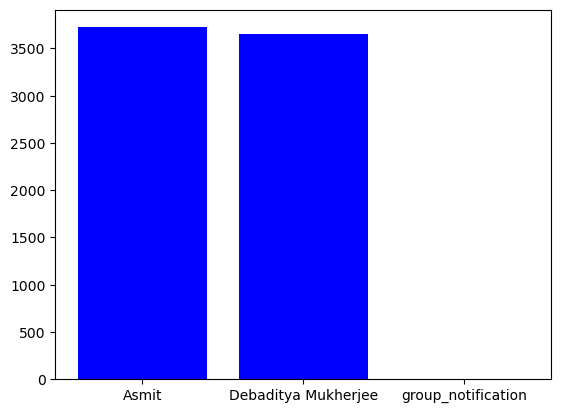

In [21]:
plot_bar(df)

In [22]:
round((df['users'].value_counts()/df.shape[0])*100,2).reset_index().rename(columns={"index":"name","user":"percent"}) # Return the figure object


,users,count
0,Asmit,50.45
1,Debaditya Mukherjee,49.50
2,group_notification,0.05
